# Hybrid wine recommender

This notebook combines two already-built parent recommenders:

- TF-IDF (imported from saved recommendations)
- ALS (imported from saved recommendations)

Then it tests a weighted hybrid of the two.

The goal is to see if the hybrid works better than either parent model on the same shared 5000-user split used in the rest of the project.

In [25]:
import warnings
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

HYBRID_WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0]
PARENT_TOP_N = 100


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'dataset').exists() and (candidate / 'EDA').exists():
            return candidate
    raise FileNotFoundError('Project root with dataset/ and EDA/ not found')


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / 'dataset'
SHARED_SPLIT_DIR = PROJECT_ROOT / 'data' / 'results' / 'shared_split'
ARMS_DIR = PROJECT_ROOT / 'bandits' / 'saved_arms'

TFIDF_RECS_PATH = ARMS_DIR / 'content_tfidf_recs.csv'
ALS_RECS_PATH = ARMS_DIR / 'als_recs.csv'

print('Project root :', PROJECT_ROOT)
print('Dataset dir  :', DATASET_DIR)
print('Shared split :', SHARED_SPLIT_DIR)
print('Arms dir     :', ARMS_DIR)
print('TF-IDF recs  :', TFIDF_RECS_PATH)
print('ALS recs     :', ALS_RECS_PATH)

Project root : /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system
Dataset dir  : /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/dataset
Shared split : /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/shared_split
Arms dir     : /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/bandits/saved_arms
TF-IDF recs  : /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/bandits/saved_arms/content_tfidf_recs.csv
ALS recs     : /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/bandits/saved_arms/als_recs.csv


## 1. Load shared split and parent outputs

We align this notebook with the rest of the project:

- load `train_pos.csv` and `test_pos.csv` from `data/results/shared_split/`
- import precomputed TF-IDF and ALS recommendations from `bandits/saved_arms/`
- evaluate everything on the same shared users

In [26]:
wine_cols = ['WineID', 'WineName', 'Type', 'Country', 'RegionName', 'Body', 'Acidity']

wines = pd.read_csv(
    DATASET_DIR / 'XWines_Full_100K_wines.csv',
    usecols=wine_cols,
    dtype={
        'WineID': 'int32',
        'WineName': 'string',
        'Type': 'category',
        'Country': 'category',
        'RegionName': 'string',
        'Body': 'category',
        'Acidity': 'category',
    },
)
wines = wines.drop_duplicates(subset='WineID').copy()

train_pos = pd.read_csv(
    SHARED_SPLIT_DIR / 'train_pos.csv',
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)
test_pos = pd.read_csv(
    SHARED_SPLIT_DIR / 'test_pos.csv',
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)

train_pos = train_pos[train_pos['WineID'].isin(wines['WineID'])].copy()
test_pos = test_pos[test_pos['WineID'].isin(wines['WineID'])].copy()

shared_users = sorted(set(train_pos['UserID']) & set(test_pos['UserID']))
train_seen = train_pos.groupby('UserID')['WineID'].apply(set).to_dict()
test_relevant = test_pos.groupby('UserID')['WineID'].apply(set).to_dict()

print('Wines            :', wines.shape)
print('Train positives  :', train_pos.shape)
print('Test positives   :', test_pos.shape)
print('Shared users     :', len(shared_users))

Wines            : (100646, 7)
Train positives  : (56673, 3)
Test positives   : (16646, 3)
Shared users     : 5000


## 2. Load TF-IDF parent recommender output

Instead of re-training TF-IDF here, we import the existing TF-IDF recommendations exported by the content-based notebook.

In [27]:
def load_parent_recs(path: Path, users, top_n=PARENT_TOP_N):
    if not path.exists():
        raise FileNotFoundError(f'Parent recommender file not found: {path}')

    df = pd.read_csv(path, dtype={'UserID': 'int32', 'rank': 'int32', 'WineID': 'int32'})
    req = {'UserID', 'rank', 'WineID'}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f'{path.name} missing required columns: {missing}')

    df = df[df['rank'] <= top_n].copy()
    df = df[df['UserID'].isin(users)].copy()
    df = df.sort_values(['UserID', 'rank'])

    recs_by_user = df.groupby('UserID')['WineID'].apply(list).to_dict()
    return df, recs_by_user


tfidf_recs_df, tfidf_recs_by_user = load_parent_recs(TFIDF_RECS_PATH, shared_users, top_n=PARENT_TOP_N)
print('TF-IDF imported rec rows:', tfidf_recs_df.shape)
print('TF-IDF users available  :', len(tfidf_recs_by_user))

TF-IDF imported rec rows: (500000, 3)
TF-IDF users available  : 5000


## 3. Load ALS parent recommender output

Instead of re-training ALS here, we import the existing ALS recommendations exported by the collaborative filtering notebook.

In [28]:
als_recs_df, als_recs_by_user = load_parent_recs(ALS_RECS_PATH, shared_users, top_n=PARENT_TOP_N)
print('ALS imported rec rows:', als_recs_df.shape)
print('ALS users available  :', len(als_recs_by_user))


def ranklist_to_score_map(rec_list):
    # Convert ranks to [0,1] scores: rank 1 -> 1.0, rank N -> 1/N.
    n = len(rec_list)
    if n == 0:
        return {}
    return {int(wine_id): (n - idx) / n for idx, wine_id in enumerate(rec_list)}


tfidf_scores_by_user = {u: ranklist_to_score_map(lst) for u, lst in tfidf_recs_by_user.items()}
als_scores_by_user = {u: ranklist_to_score_map(lst) for u, lst in als_recs_by_user.items()}

print('TF-IDF score maps:', len(tfidf_scores_by_user))
print('ALS score maps   :', len(als_scores_by_user))

ALS imported rec rows: (500000, 3)
ALS users available  : 5000
TF-IDF score maps: 5000
ALS score maps   : 5000


## 4. Evaluate the models

We compare three cases:

- pure ALS
- pure TF-IDF
- weighted hybrids

Here, 0.0 means pure ALS and 1.0 means pure TF-IDF.

,Accuracy@5,Recall@5,NDCG@5,Diversity@5,Accuracy@10,Recall@10,NDCG@10,Diversity@10,Accuracy@20,Recall@20,NDCG@20,Diversity@20,Coverage,Personalisation@10,EvalUsers,TFIDF_weight
Model,,,,,,,,,,,,,,,,
ALS,0.0062,0.0088,0.0086,0.5390,0.0052,0.0143,0.0105,0.5604,0.0043,0.0233,0.0137,0.5819,0.0725,0.9940,5000,NaN
TF-IDF,0.0052,0.0096,0.0087,0.1536,0.0041,0.0146,0.0106,0.1625,0.0029,0.0211,0.0126,0.1692,0.1784,0.9964,5000,NaN
Hybrid (TF-IDF=0.00),0.0062,0.0088,0.0086,0.5390,0.0052,0.0143,0.0105,0.5604,0.0043,0.0233,0.0137,0.5819,0.0725,0.9940,5000,0.00
Hybrid (TF-IDF=0.25),0.0075,0.0110,0.0108,0.5140,0.0057,0.0162,0.0125,0.5491,0.0045,0.0249,0.0155,0.5763,0.0728,0.9939,5000,0.25
Hybrid (TF-IDF=0.50),0.0083,0.0139,0.0136,0.4027,0.0066,0.0218,0.0164,0.4284,0.0049,0.0308,0.0194,0.4486,0.1358,0.9962,5000,0.50
Hybrid (TF-IDF=0.75),0.0067,0.0123,0.0119,0.1575,0.0048,0.0170,0.0135,0.1633,0.0033,0.0234,0.0154,0.1695,0.1771,0.9966,5000,0.75
Hybrid (TF-IDF=1.00),0.0052,0.0096,0.0087,0.1536,0.0041,0.0146,0.0106,0.1625,0.0029,0.0211,0.0126,0.1692,0.1784,0.9964,5000,1.00


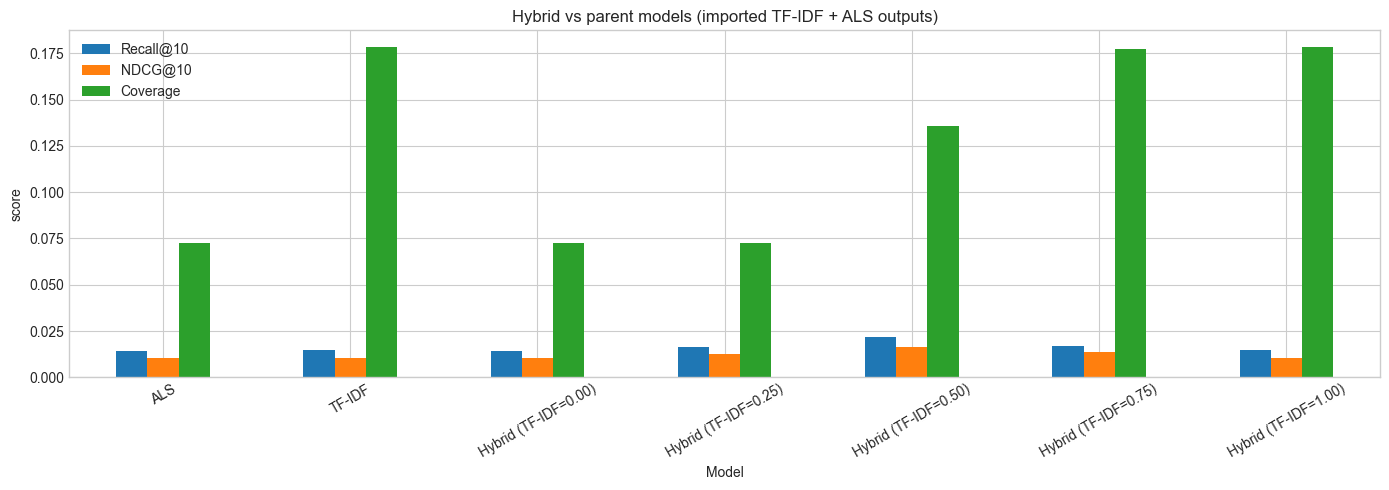

In [29]:
item_meta = wines.set_index('WineID')[['Type', 'Country']].copy()
item_meta['Type'] = item_meta['Type'].astype(str).str.lower().fillna('unknown')
item_meta['Country'] = item_meta['Country'].astype(str).str.lower().fillna('unknown')
item_signatures = {
    wine_id: {f"type:{row['Type']}", f"country:{row['Country']}"}
    for wine_id, row in item_meta.iterrows()
}


def accuracy_at_k(relevant, recommended, k):
    if k == 0:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / k


def recall_at_k(relevant, recommended, k):
    if not relevant:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / len(relevant)


def dcg_at_k(relevant, recommended, k):
    score = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            score += 1.0 / np.log2(rank + 1)
    return score


def ndcg_at_k(relevant, recommended, k):
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg_at_k(relevant, recommended, k) / idcg


def jaccard_distance(a, b):
    union = len(a | b)
    return 0.0 if union == 0 else 1.0 - (len(a & b) / union)


def intra_list_diversity(recommended):
    if len(recommended) < 2:
        return 0.0
    vals = []
    for i in range(len(recommended)):
        for j in range(i + 1, len(recommended)):
            vals.append(
                jaccard_distance(
                    item_signatures.get(recommended[i], {'unknown'}),
                    item_signatures.get(recommended[j], {'unknown'}),
                )
            )
    return float(np.mean(vals)) if vals else 0.0


def personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=RANDOM_STATE):
    users = list(recs_by_user.keys())
    if len(users) < 2:
        return 0.0
    rng = np.random.default_rng(random_state)
    if len(users) > max_users:
        users = rng.choice(users, size=max_users, replace=False).tolist()
    top_k_sets = {user_id: set(recs_by_user[user_id][:k]) for user_id in users}
    overlaps = []
    for user_a, user_b in itertools.combinations(users, 2):
        a, b = top_k_sets[user_a], top_k_sets[user_b]
        union = len(a | b)
        overlaps.append((len(a & b) / union) if union > 0 else 0.0)
    return float(1.0 - np.mean(overlaps)) if overlaps else 0.0


def recommend_tfidf_ids(user_id, top_k=10):
    seen = train_seen.get(user_id, set())
    recs = [wid for wid in tfidf_recs_by_user.get(user_id, []) if wid not in seen]
    return recs[:top_k]


def recommend_als_ids(user_id, top_k=10):
    seen = train_seen.get(user_id, set())
    recs = [wid for wid in als_recs_by_user.get(user_id, []) if wid not in seen]
    return recs[:top_k]


def recommend_hybrid_ids(user_id, tfidf_weight=0.5, top_k=10):
    seen = train_seen.get(user_id, set())

    tfidf_map = tfidf_scores_by_user.get(user_id, {})
    als_map = als_scores_by_user.get(user_id, {})
    candidate_ids = (set(tfidf_map) | set(als_map)) - set(seen)

    if not candidate_ids:
        return []

    scored = []
    for wine_id in candidate_ids:
        score = tfidf_weight * tfidf_map.get(wine_id, 0.0) + (1.0 - tfidf_weight) * als_map.get(wine_id, 0.0)
        scored.append((score, int(wine_id)))

    scored.sort(key=lambda x: (x[0], x[1]), reverse=True)
    return [wine_id for _, wine_id in scored[:top_k]]


def evaluate_recommender(recommend_func, users, relevant_dict, ks=(5, 10, 20)):
    rows = []
    recs_by_user = {}
    all_top10_items = []
    max_k = max(ks)
    for user_id in users:
        relevant = relevant_dict.get(user_id, set())
        if not relevant:
            continue
        recs = recommend_func(user_id, top_k=max_k)
        if not recs:
            continue
        recs_by_user[user_id] = recs
        all_top10_items.extend(recs[:10])
        row = {'UserID': user_id}
        for k in ks:
            row[f'Accuracy@{k}'] = accuracy_at_k(relevant, recs, k)
            row[f'Recall@{k}'] = recall_at_k(relevant, recs, k)
            row[f'NDCG@{k}'] = ndcg_at_k(relevant, recs, k)
            row[f'Diversity@{k}'] = intra_list_diversity(recs[:k])
        rows.append(row)

    eval_df = pd.DataFrame(rows)
    if eval_df.empty:
        return eval_df, {}

    coverage = len(set(all_top10_items)) / len(wines) if len(wines) else 0.0
    pers = personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=RANDOM_STATE)
    extras = {'Coverage': coverage, 'Personalisation@10': pers, 'EvalUsers': len(eval_df)}
    return eval_df, extras


available_eval_users = sorted(
    set(shared_users)
    & set(test_relevant.keys())
    & (set(tfidf_recs_by_user.keys()) | set(als_recs_by_user.keys()))
)

model_summaries = []

for label, func in [
    ('ALS', recommend_als_ids),
    ('TF-IDF', recommend_tfidf_ids),
]:
    eval_df, extras = evaluate_recommender(func, available_eval_users, test_relevant)
    if eval_df.empty:
        continue
    summary = eval_df.drop(columns='UserID').mean().to_dict()
    summary.update(extras)
    summary['Model'] = label
    model_summaries.append(summary)

for weight in HYBRID_WEIGHTS:
    label = f'Hybrid (TF-IDF={weight:.2f})'
    eval_df, extras = evaluate_recommender(
        lambda user_id, top_k, weight=weight: recommend_hybrid_ids(user_id, tfidf_weight=weight, top_k=top_k),
        available_eval_users,
        test_relevant,
    )
    if eval_df.empty:
        continue
    summary = eval_df.drop(columns='UserID').mean().to_dict()
    summary.update(extras)
    summary['Model'] = label
    summary['TFIDF_weight'] = weight
    model_summaries.append(summary)

summary_df = pd.DataFrame(model_summaries).set_index('Model').round(4)
display(summary_df)

comparison_cols = ['Recall@10', 'NDCG@10', 'Coverage']
avail_cols = [c for c in comparison_cols if c in summary_df.columns]
summary_df[avail_cols].plot(kind='bar', figsize=(14, 5), rot=30)
plt.title('Hybrid vs parent models (imported TF-IDF + ALS outputs)')
plt.ylabel('score')
plt.tight_layout()
plt.show()

This graph shows that our hybrid is now actually using TF-IDF, not just ALS. We can see that because when the TF-IDF weight increases, coverage goes up a lot, which means the model is recommending a wider variety of wines from the catalog. At the same time, ranking quality does not improve in a straight line. It gets best around the middle, especially near the 0.50 to 0.75 range, and then drops again when TF-IDF becomes too dominant.

Overall, ALS is still a strong base for relevance, TF-IDF helps us explore more wines, and the best result comes from mixing them instead of using only one. Pure TF-IDF gives very high coverage, but not the best ranking quality, and pure ALS gives stable relevance but narrower recommendations. The hybrid in the middle gives the best balance.

## 5. Interpret the results

Use `summary_df` to compare pure ALS, pure TF-IDF, and weighted hybrids on the same shared split.

Recommended reading pattern:

- first compare `NDCG@10` and `Recall@10` for ranking quality
- then check `Coverage` and `Personalisation@10` for catalog spread and user-level differentiation
- finally identify whether a mixed weight beats both parent-only settings

In [30]:
hybrid_only = summary_df[summary_df.index.str.contains('Hybrid')].copy()
if not hybrid_only.empty:
    best_hybrid = hybrid_only.sort_values(['NDCG@10', 'Recall@10'], ascending=False).head(1)
    display(best_hybrid)
    best_name = best_hybrid.index[0]
    best_weight = float(best_hybrid['TFIDF_weight'].iloc[0])
    print(f'Best hybrid setting: {best_name} (TF-IDF weight={best_weight:.2f})')

,Accuracy@5,Recall@5,NDCG@5,Diversity@5,Accuracy@10,Recall@10,NDCG@10,Diversity@10,Accuracy@20,Recall@20,NDCG@20,Diversity@20,Coverage,Personalisation@10,EvalUsers,TFIDF_weight
Model,,,,,,,,,,,,,,,,
Hybrid (TF-IDF=0.50),0.0083,0.0139,0.0136,0.4027,0.0066,0.0218,0.0164,0.4284,0.0049,0.0308,0.0194,0.4486,0.1358,0.9962,5000,0.5


Best hybrid setting: Hybrid (TF-IDF=0.50) (TF-IDF weight=0.50)


## 6. Business takeaway

This setup gives a fair project-level comparison because it reuses:

- the same shared 5000-user split
- the same already-exported parent recommenders

If a hybrid weight beats both parent models on ranking metrics while keeping acceptable coverage, that weight is the best candidate for presentation and further deployment experiments.

In [31]:
from pathlib import Path
import pandas as pd

ARMS_DIR = Path("../bandits/saved_arms")
ARMS_DIR.mkdir(parents=True, exist_ok=True)

def export_arm_recs(recommend_fn, users, out_csv, top_k=100):
    rows = []
    for uid in users:
        recs = recommend_fn(int(uid), top_k=top_k)
        for r, wid in enumerate(recs, start=1):
            rows.append({"UserID": int(uid), "rank": int(r), "WineID": int(wid)})
    out_df = pd.DataFrame(rows)
    out_df.to_csv(out_csv, index=False)
    print(f"Saved {len(out_df):,} rows -> {out_csv}")

In [32]:
export_weight = float(best_weight) if 'best_weight' in globals() else 0.50
print(f'Exporting hybrid recommendations with TF-IDF weight={export_weight:.2f}')

export_arm_recs(
    recommend_fn=lambda uid, top_k=100, w=export_weight: recommend_hybrid_ids(uid, tfidf_weight=w, top_k=top_k),
    users=available_eval_users,
    out_csv=ARMS_DIR / "hybrid_tfidf_als_recs.csv",
    top_k=100
)

Exporting hybrid recommendations with TF-IDF weight=0.50
Saved 500,000 rows -> ../bandits/saved_arms/hybrid_tfidf_als_recs.csv
